# Algoritmos Genéticos: Asesor de Inversiones en Bonos

Daniela Lizet Cauich Lopez

**Problema:** Encontrar la combinación de bonos que **maximice el rendimiento** sin superar el capital disponible.

__Descripción del problema__

* Una empresa ofrece a sus clientes invertir en bonos de varias compañías.  
* Cada bono tiene tres características: **precio**, **rendimiento** y **cantidad disponible**.  
* El objetivo es encontrar la combinación de bonos que **maximice el rendimiento** sin superar el capital disponible.

| Bono | Precio | Cantidad disponible | Rendimiento |
|------|--------|----------------------|-------------|
| A    | 500    | 5                    | 0.15        |
| B    | 700    | 6                    | 0.05        |
| C    | 300    | 10                   | 0.03        |
| D    | 800    | 3                    | 0.10        |
| E    | 400    | 7                    | 0.10        |



## Librerías y Datos del Problema

In [1]:
from random import random, randint, sample, seed
from collections import namedtuple
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

Inversion = namedtuple('Inversion', 'nombre precio cantidad rendim')

inversiones = [
    Inversion('A', precio=500,  cantidad=5,  rendim=0.15),
    Inversion('B', precio=700,  cantidad=6,  rendim=0.05),
    Inversion('C', precio=300,  cantidad=10, rendim=0.03),
    Inversion('D', precio=800,  cantidad=3,  rendim=0.10),
    Inversion('E', precio=400,  cantidad=7,  rendim=0.10),
]

NOMBRES   = [inv.nombre for inv in inversiones]
CAPITAL   = 5000 
SEED      = 42

## PARTE 1. Algoritmo Genético 
(Benítez Iglesias, 2014)

### 1.1  Función Objetivo y Fitness

Un individuo es una lista [n_A, n_B, n_C, n_D, n_E] que indica cuántos bonos de cada tipo se compran.

- Capital invertido = Σ (cantidad_i × precio_i)
- Rendimiento = Σ (cantidad_i × precio_i × rendimiento_i)  <- función objetivo / fitness

In [2]:
def capitalInvertido(individuo):
    #Calcula el capital total invertido por un individuo
    return sum(x * y.precio for x, y in zip(individuo, inversiones))

def rendimiento(individuo):
    #Calcula el rendimiento total (fitness), se maximiza
    return sum(x * y.precio * y.rendim for x, y in zip(individuo, inversiones))

# Reparación: ajusta si supera el capital
def ajustaCapital(individuo):
    # Si el capital invertido supera el disponible, elimina bonos al azar
    ajustado = individuo[:]
    while capitalInvertido(ajustado) > CAPITAL:
        pos = randint(0, len(ajustado) - 1)
        if ajustado[pos] > 0:
            ajustado[pos] -= 1
    return ajustado

### 1.2  Operadores Genéticos

In [3]:
# Selección: creación de individuo válido
def creaIndividuo():
    
    # Operador de selección / Inicialización
    # Crea un individuo al azar que no supere el capital disponible
    individuo = [0] * len(inversiones)
    while capitalInvertido(individuo) < CAPITAL:
        eleccion = randint(0, len(inversiones) - 1)
        #respeta la cantidad máxima disponible de cada bono
        if individuo[eleccion] < inversiones[eleccion].cantidad:
            individuo[eleccion] += 1
    return ajustaCapital(individuo)

# Cruza: cruce de un punto variable
def cruza(poblacion, posiciones):
    """
    Operador de CRUZA.
    Toma los genes del primer progenitor y luego toma al azar
    un segmento de entre 1 y L genes del segundo progenitor
    """
    L = len(poblacion[0])
    hijo   = poblacion[posiciones[0]][:]
    inicio = randint(0, L - 1)
    fin    = randint(inicio + 1, L)
    hijo[inicio:fin] = poblacion[posiciones[1]][inicio:fin]
    return ajustaCapital(hijo)

# Mutación: cambio aleatorio según tasa 
def muta(individuo, tasaMutacion=0.01):
    """
    Operador de MUTACIÓN.
    Aplica mutaciones según una tasa dada; garantiza que se cumplan
    las restricciones de capital y cantidades disponibles.
    """
    mutado = []
    for i in range(len(individuo)):
        if random() > tasaMutacion:
            mutado.append(individuo[i])
        else:
            # Muta a un valor aleatorio dentro del máximo disponible
            mutado.append(randint(0, inversiones[i].cantidad))
    return ajustaCapital(mutado)

### 1.3  Ciclo Evolutivo

In [4]:
def evoluciona(poblacion, generaciones, tasaMutacion=0.01):
    """
    Hace evolucionar el sistema durante un número de generaciones.
    Usa selección proporcional al rango (reproduccion) + elitismo.
    Devuelve el mejor individuo encontrado y el historial de fitness.
    """
    # Ordenar por rendimiento ascendente (el mejor queda al final)
    poblacion.sort(key=lambda x: rendimiento(x))
    N = len(poblacion)
    tasaMutacion = tasaMutacion

    # Lista de reproducción proporcional al rango
    # [0, 1,1, 2,2,2, ...] — individuos con mayor rango tienen más copias
    reproduccion = [x for x in range(N) for _ in range(x + 1)]

    historial = [rendimiento(poblacion[-1])]  # mejor fitness inicial

    for _ in range(generaciones):
        # Generar N-1 hijos cruzando padres distintos
        padres = sample(reproduccion, 2)
        while padres[0] == padres[1]:
            padres = sample(reproduccion, 2)

        hijos = [cruza(poblacion, padres) for _ in range(N - 1)]

        # Aplicar mutaciones
        hijos = [muta(x, tasaMutacion) for x in hijos]

        # Elitismo: conservar el mejor individuo de la generación anterior
        hijos.append(poblacion[-1])
        poblacion = hijos
        poblacion.sort(key=lambda x: rendimiento(x))

        historial.append(rendimiento(poblacion[-1]))

    return poblacion[-1], historial

### 1.4  Ejecución del AG Manual

In [6]:
seed(SEED)

INDIVIDUOS   = 30
GENERACIONES = 500

# población inicial
poblacion_manual = [creaIndividuo() for _ in range(INDIVIDUOS)]

#evolucionar
mejor_manual, hist_manual = evoluciona(poblacion_manual, GENERACIONES)

#resultados
print("RESULTADOS")
print("-"*55)
for i, bono in enumerate(inversiones):
    print(f"  Bono {bono.nombre}: {mejor_manual[i]:>2} unidad(es)  "
          f"(${mejor_manual[i]*bono.precio:,})")
print("-"*55)
print(f"  Capital invertido : ${capitalInvertido(mejor_manual):,.2f} / ${CAPITAL:,}")
print(f"  Rendimiento total : ${rendimiento(mejor_manual):,.2f}")

RESULTADOS
-------------------------------------------------------
  Bono A:  5 unidad(es)  ($2,500)
  Bono B:  0 unidad(es)  ($0)
  Bono C:  0 unidad(es)  ($0)
  Bono D:  2 unidad(es)  ($1,600)
  Bono E:  2 unidad(es)  ($800)
-------------------------------------------------------
  Capital invertido : $4,900.00 / $5,000
  Rendimiento total : $615.00


## PARTE 2. Algoritmo Genético con DEAP

### 2.1  Configuración de DEAP

In [7]:
from deap import base, creator, tools, algorithms
import random as rnd

rnd.seed(SEED)

#Definición del problema: MAXIMIZACIÓN
if not hasattr(creator, 'FitnessMax'):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, 'Individual'):
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

#Función de inicialización de genes
#cada gen i ∈ [0, cantidad_máxima_del_bono_i]
def gen_aleatorio(idx):
    return rnd.randint(0, inversiones[idx].cantidad)

def crear_individuo_deap():
    #Crea un individuo DEAP respetando capital y cantidades máximas
    ind = creator.Individual([gen_aleatorio(i) for i in range(len(inversiones))])
    #Reparar si supera el capital
    reparado = ajustaCapital(list(ind))
    ind[:] = reparado
    return ind

toolbox.register("individual", crear_individuo_deap)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

### 2.2  Función Objetivo / Fitness en DEAP

nota: DEAP requiere que el fitness devuelva una tupla (incluso para un solo objetivo)

In [12]:
#Función de evaluación(fi†neess)
def evaluar(individuo):
    #DEAP requiere que la función de evaluación devuelva una TUPLA.
    #Penalización: si supera el capital -> rendimiento = 0
    
    if capitalInvertido(individuo) > CAPITAL:
        return (0.0,)          #penalización
    return (rendimiento(individuo),)

toolbox.register("evaluate", evaluar)

### 2.3  Operadores en DEAP

In [14]:
#SELECCIÓN: torneo de tamaño 3
toolbox.register("select", tools.selTournament, tournsize=3)

#CRUZA: cruce de dos puntos
def cruza_deap(ind1, ind2):
    #Cruce de dos puntos + reparación de restricciones
    tools.cxTwoPoint(ind1, ind2)
    ind1[:] = ajustaCapital(list(ind1))
    ind2[:] = ajustaCapital(list(ind2))
    return ind1, ind2

toolbox.register("mate", cruza_deap)

#MUTACIÓN: uniforme por entero + reparación
def muta_deap(individuo, tasa=0.2):
    #Muta cada gen con cierta probabilidad; respeta cantidades máximas
    for i in range(len(individuo)):
        if rnd.random() < tasa:
            individuo[i] = rnd.randint(0, inversiones[i].cantidad)
    individuo[:] = ajustaCapital(list(individuo))
    return (individuo,)

toolbox.register("mutate", muta_deap)

### 2.4  Ejecución del AG con DEAP

In [15]:
rnd.seed(SEED)

POP_SIZE   = INDIVIDUOS
NGEN       = GENERACIONES
CXPB       = 0.8    #probabilidad de cruza
MUTPB      = 0.2    #probabilidad de mutación

#población inicial
poblacion_deap = toolbox.population(n=POP_SIZE)

#estadísticas
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max",  np.max)
stats.register("mean", np.mean)
stats.register("min",  np.min)

#Hall of Fame: guarda el mejor individuo de toda la evolución
hof = tools.HallOfFame(1)

poblacion_deap, logbook = algorithms.eaMuPlusLambda(
    poblacion_deap,
    toolbox,
    mu=POP_SIZE,
    lambda_=POP_SIZE,
    cxpb=CXPB,
    mutpb=MUTPB,
    ngen=NGEN,
    stats=stats,
    halloffame=hof,
    verbose=False
)

mejor_deap  = hof[0]
hist_deap   = logbook.select("max")

print("  RESULTADO. Algoritmo Genético (DEAP)")
print("-"*55)
for i, bono in enumerate(inversiones):
    print(f"  Bono {bono.nombre}: {mejor_deap[i]:>2} unidad(es)  "
          f"(${mejor_deap[i]*bono.precio:,})")
print("-"*55)
print(f"  Capital invertido : ${capitalInvertido(mejor_deap):,.2f} / ${CAPITAL:,}")
print(f"  Rendimiento total : ${rendimiento(mejor_deap):,.2f}")

  RESULTADO. Algoritmo Genético (DEAP)
-------------------------------------------------------
  Bono A:  5 unidad(es)  ($2,500)
  Bono B:  0 unidad(es)  ($0)
  Bono C:  0 unidad(es)  ($0)
  Bono D:  1 unidad(es)  ($800)
  Bono E:  4 unidad(es)  ($1,600)
-------------------------------------------------------
  Capital invertido : $4,900.00 / $5,000
  Rendimiento total : $615.00


## PARTE 3. Gráfica

### 3.1  Bonos a comprar. Mejor solución

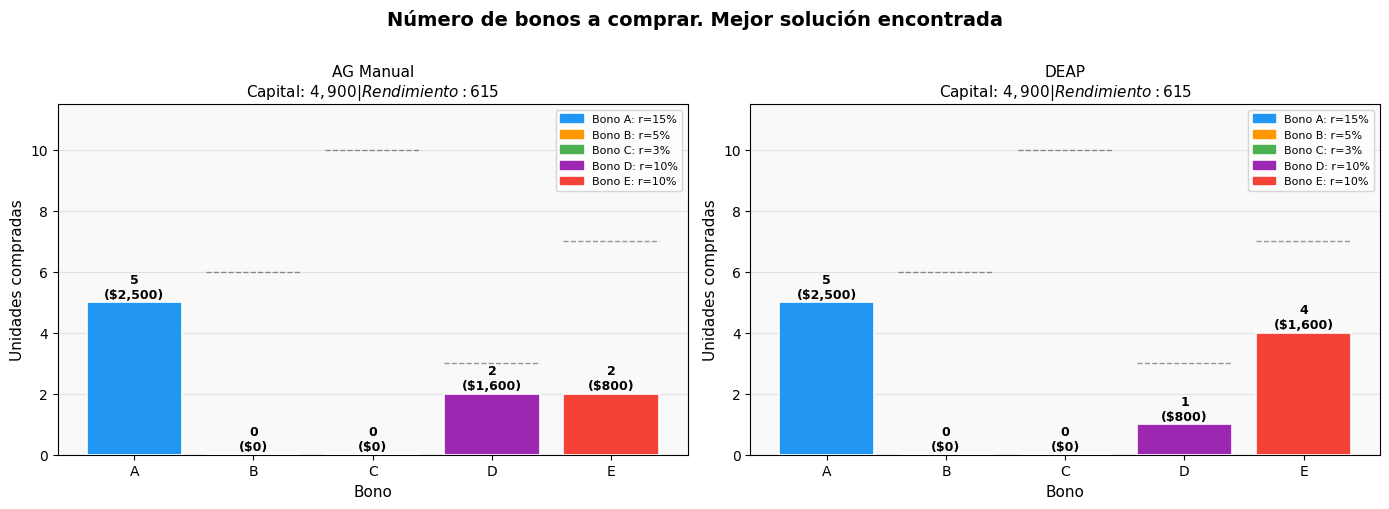

La línea punteada indica la cantidad máxima disponible de cada bono.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Número de bonos a comprar. Mejor solución encontrada",
             fontsize=14, fontweight='bold', y=1.01)

colores = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']

for ax, (titulo, mejor) in zip(
        axes,
        [("AG Manual", mejor_manual), ("DEAP", mejor_deap)]):

    bars = ax.bar(NOMBRES, mejor, color=colores, edgecolor='white',
                  linewidth=1.2, zorder=3)

    #cantidad máxima disponible (línea punteada)
    for i, inv in enumerate(inversiones):
        ax.plot([i - 0.4, i + 0.4], [inv.cantidad, inv.cantidad],
                'k--', linewidth=1, alpha=0.4)

    #etiquetas de las barras
    for bar, val, inv in zip(bars, mejor, inversiones):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val}\n(${val*inv.precio:,})',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(
        f"{titulo}\n"
        f"Capital: ${capitalInvertido(mejor):,} | "
        f"Rendimiento: ${rendimiento(mejor):,.0f}",
        fontsize=11
    )
    ax.set_xlabel("Bono", fontsize=11)
    ax.set_ylabel("Unidades compradas", fontsize=11)
    ax.set_ylim(0, max(inv.cantidad for inv in inversiones) + 1.5)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.set_facecolor('#f9f9f9')

    #rendimiento por bono
    patches = [mpatches.Patch(color=colores[i],
               label=f'Bono {inv.nombre}: r={inv.rendim:.0%}')
               for i, inv in enumerate(inversiones)]
    ax.legend(handles=patches, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()
print("La línea punteada indica la cantidad máxima disponible de cada bono.")

## PARTE 4. Comparaciones

### 4.1  Diferencias en la Función Objetivo


**AG Manual:**
```python
def rendimiento(ind):
    return sum(x * y.precio * y.rendim
               for x, y in zip(ind, inversiones))
```
**DEAP:**
```python
def evaluar(ind):
    if capitalInvertido(ind) > CAPITAL:
        return (0.0,)   # penalización
    return (rendimiento(ind),)
```

| | AG Manual | DEAP |
|---|---|---|
| **Código** | `rendimiento(ind)` retorna `float` | `evaluar(ind)` retorna `tuple` |
| **Restricción** | Manejada por `ajustaCapital()` | Penalización explícita → `return (0.0,)` |
| **Tipo de retorno** | `float` | `(float,)` — tupla obligatoria |
| **Maximización** | Implícita en el `sort()` | Declarada con `weights=(+1.0,)` |



### 4.2  Diferencias en la Programación del Fitness


**AG Manual, configuración mínima:**
```python
# No hay declaración formal, el fitness es solo una función
poblacion.sort(key=lambda x: rendimiento(x))
```

**DEAP, configuración estructurada:**
```python
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # maximizar
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox.register("evaluate", evaluar)
```

| | AG Manual | DEAP |
|---|---|---|
| **Función** | `rendimiento(ind)` llamada directamente | Registrada con `toolbox.register("evaluate", evaluar)` |
| **Dónde se usa** | En `sort()` y comparaciones manuales | Almacenada en `ind.fitness.values` |
| **Estructura** | Sin estructura formal | `creator.create("FitnessMax", base.Fitness, weights=(1.0,))` |
| **Invalidación** | Manual: el programador la controla | Automática tras cruza/mutación |



### 4.3  Diferencias en Selección, Cruza y Mutación


| Operador | AG Manual | DEAP |
|---|---|---|
| **Selección** | Proporcional al rango (`reproduccion[]`) + `sample()` aleatorio | `tools.selTournament(tournsize=3)` mayor presión selectiva. Alternativas: `selRoulette`, `selBest` |
| **Cruza** | Un punto variable (inicio y fin aleatorios), implementación manual | `tools.cxTwoPoint` dos puntos de corte, más diversidad, implementación optimizada en C |
| **Mutación** | Tasa fija `0.01` (conservadora) sustituye gen por `randint(0, cant)` | Tasa configurable `0.2` misma lógica pero con probabilidad por individuo (`MUTPB`) y por gen (`tasa`) |
| **Elitismo** | Explícito: `hijos.append(poblacion[-1])` siempre conserva el mejor | `eaMuPlusLambda`: selecciona el mejor de μ padres + λ hijos por diseño |

### 4.4  Resultados Finales Comparativos

In [27]:
r_manual = rendimiento(mejor_manual)
c_manual = capitalInvertido(mejor_manual)
r_deap   = rendimiento(mejor_deap)
c_deap   = capitalInvertido(mejor_deap)

print(" TABLA COMPARATIVA DE RESULTADOS")
print("-"*68)
print(f"{'Métrica':<28} {'AG Manual':>18} {'DEAP':>18}")
print("-"*68)
for i, bono in enumerate(inversiones):
    print(f"  Bono {bono.nombre} (r={bono.rendim:.0%}, p=${bono.precio})  "
          f"{mejor_manual[i]:>15} uds   "
          f"{mejor_deap[i]:>15} uds")
print("-"*68)
print(f"  {'Capital disponible':<26} ${CAPITAL:>16,}   ${CAPITAL:>16,}")
print(f"  {'Capital invertido':<26} ${c_manual:>16,.2f}   ${c_deap:>16,.2f}")
print(f"  {'Capital sin usar':<26} ${CAPITAL-c_manual:>16,.2f}   ${CAPITAL-c_deap:>16,.2f}")
print(f"  {'Rendimiento total':<26} ${r_manual:>16,.2f}   ${r_deap:>16,.2f}")
print(f"  {'ROI sobre capital inv.':<26}  {r_manual/c_manual*100:>15.2f}%    {r_deap/c_deap*100:>15.2f}%")
print("-"*68)


 TABLA COMPARATIVA DE RESULTADOS
--------------------------------------------------------------------
Métrica                               AG Manual               DEAP
--------------------------------------------------------------------
  Bono A (r=15%, p=$500)                5 uds                 5 uds
  Bono B (r=5%, p=$700)                0 uds                 0 uds
  Bono C (r=3%, p=$300)                0 uds                 0 uds
  Bono D (r=10%, p=$800)                2 uds                 1 uds
  Bono E (r=10%, p=$400)                2 uds                 4 uds
--------------------------------------------------------------------
  Capital disponible         $           5,000   $           5,000
  Capital invertido          $        4,900.00   $        4,900.00
  Capital sin usar           $          100.00   $          100.00
  Rendimiento total          $          615.00   $          615.00
  ROI sobre capital inv.                12.55%              12.55%
--------------------

## Conclusiones
Ambas técnicas obtuvieron los mismos resultados. Para proyectos de investigación o producción, DEAP ofrece mayor flexibilidad y operadores optimizados. Para aprender los fundamentos del AG, la implementación manual es más transparente y didáctica.